<h1>Table of contents</h1>

<div class="alert alert-block alert-info" style="margin-top: 20px">
    <ol>
        <li><a href="#Data">Data</a></li>
        <li><a href="#Selecting">Selecting & Preprocessing</a></li>
        <li><a href="#Model">Model</a></li>
        <li><a href="#Evaluation">Evaluation</a></li>
    </ol>
</div>
<br>
<hr>

# importing libs

In [4]:
import numpy as np
import pandas as pd
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
from scipy.stats import norm
from sklearn.metrics import r2_score
from sklearn import linear_model

<h1 id="Data">Data</h1>

In [5]:
df = pd.read_csv("../data/FuelConsumption.csv")
df

,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,2014,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,2014,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,2014,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,2014,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,2014,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1062,2014,VOLVO,XC60 AWD,SUV - SMALL,3.0,6,AS6,X,13.4,9.8,11.8,24,271
1063,2014,VOLVO,XC60 AWD,SUV - SMALL,3.2,6,AS6,X,13.2,9.5,11.5,25,264
1064,2014,VOLVO,XC70 AWD,SUV - SMALL,3.0,6,AS6,X,13.4,9.8,11.8,24,271
1065,2014,VOLVO,XC70 AWD,SUV - SMALL,3.2,6,AS6,X,12.9,9.3,11.3,25,260


In [6]:
df.describe()

,MODELYEAR,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
count,1067.0,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000
mean,2014.0,3.346298,5.794752,13.296532,9.474602,11.580881,26.441425,256.228679
std,0.0,1.415895,1.797447,4.101253,2.794510,3.485595,7.468702,63.372304
min,2014.0,1.000000,3.000000,4.600000,4.900000,4.700000,11.000000,108.000000
25%,2014.0,2.000000,4.000000,10.250000,7.500000,9.000000,21.000000,207.000000
50%,2014.0,3.400000,6.000000,12.600000,8.800000,10.900000,26.000000,251.000000
75%,2014.0,4.300000,8.000000,15.550000,10.850000,13.350000,31.000000,294.000000
max,2014.0,8.400000,12.000000,30.200000,20.500000,25.800000,60.000000,488.000000


<h1 id="2">Selecting & Preprocessing</h1>

In [7]:
cdf = df[["ENGINESIZE","CYLINDERS","FUELCONSUMPTION_COMB","CO2EMISSIONS"]]
cdf

,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_COMB,CO2EMISSIONS
0,2.0,4,8.5,196
1,2.4,4,9.6,221
2,1.5,4,5.9,136
3,3.5,6,11.1,255
4,3.5,6,10.6,244
...,...,...,...,...
1062,3.0,6,11.8,271
1063,3.2,6,11.5,264
1064,3.0,6,11.8,271
1065,3.2,6,11.3,260


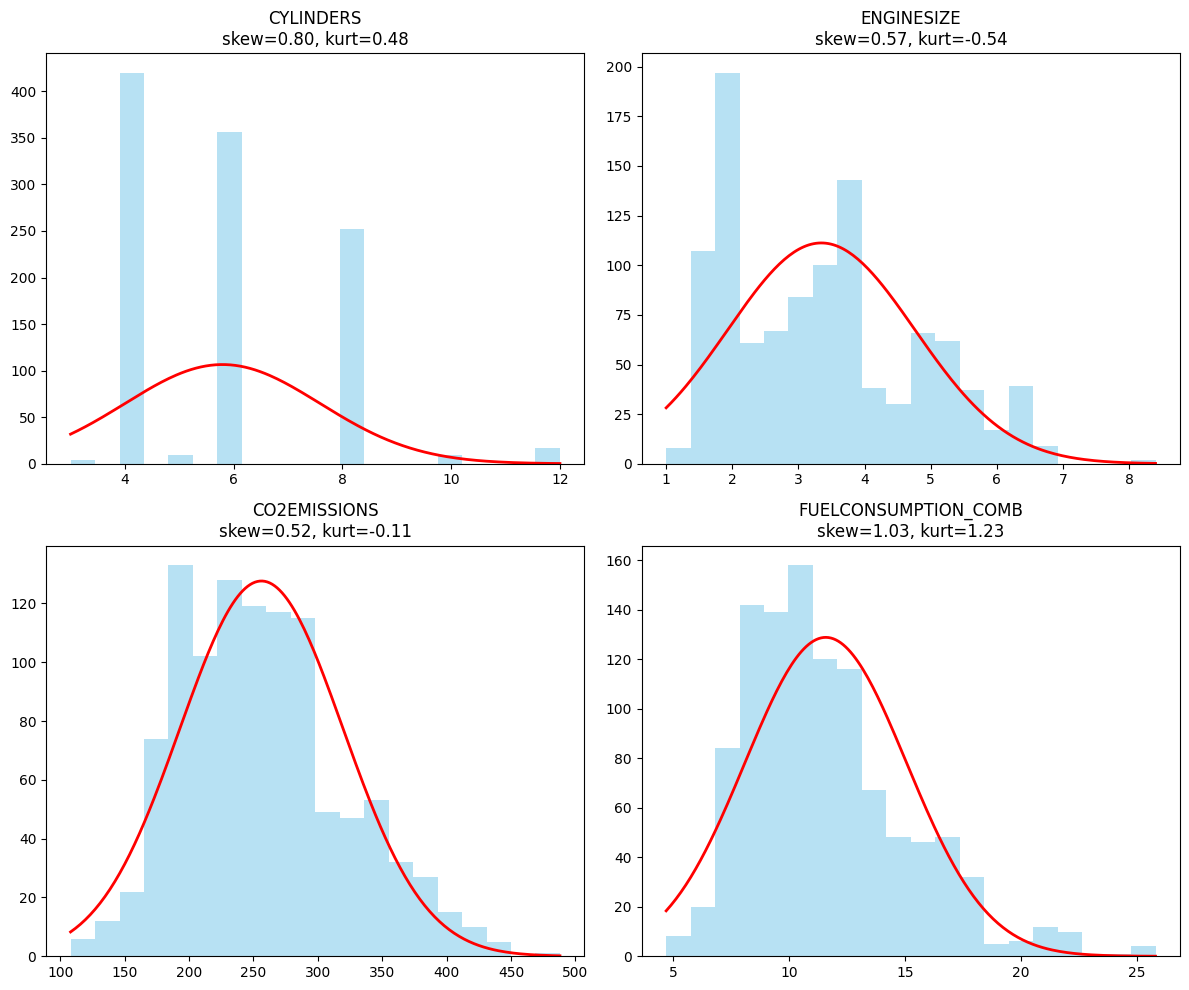

In [8]:
viz = cdf[['CYLINDERS','ENGINESIZE','CO2EMISSIONS','FUELCONSUMPTION_COMB']]

plt.figure(figsize=(12,10))

for i, col in enumerate(viz.columns):
    data = viz[col]
    mu = data.mean()
    sigma = data.std()
    
    skew = data.skew()
    kurt = data.kurt()

    plt.subplot(2, 2, i+1)

    counts, bins, _ = plt.hist(data, bins=20, alpha=0.6, color='skyblue')

    x = np.linspace(data.min(), data.max(), 200)
    y = norm.pdf(x, mu, sigma)
    y = y * len(data) * (bins[1] - bins[0])  

    plt.plot(x, y, 'r', linewidth=2)


    plt.title(f"{col}\nskew={skew:.2f}, kurt={kurt:.2f}")

plt.tight_layout()
plt.show()


# seperating values
### 2 groups(80 20) :
- train
- test

In [9]:
mask = np.random.randn(len(cdf)) < 0.8
train = cdf[mask]
test = cdf[~mask]

<h1 id = "Model">Model</h1>
<h5>Multi_regression(OLS)</h5>

In [10]:
regr = linear_model.LinearRegression()
x_train = np.asanyarray(train[["ENGINESIZE","CYLINDERS","FUELCONSUMPTION_COMB"]])
y_train = np.asanyarray(train[["CO2EMISSIONS"]])
regr.fit(x_train,y_train)
print(regr.coef_[0][0],regr.coef_[0][1],regr.coef_[0][2])
print(regr.intercept_[0])

11.320461000130326 7.9614436499967045 9.11581330585894
66.29162954735781


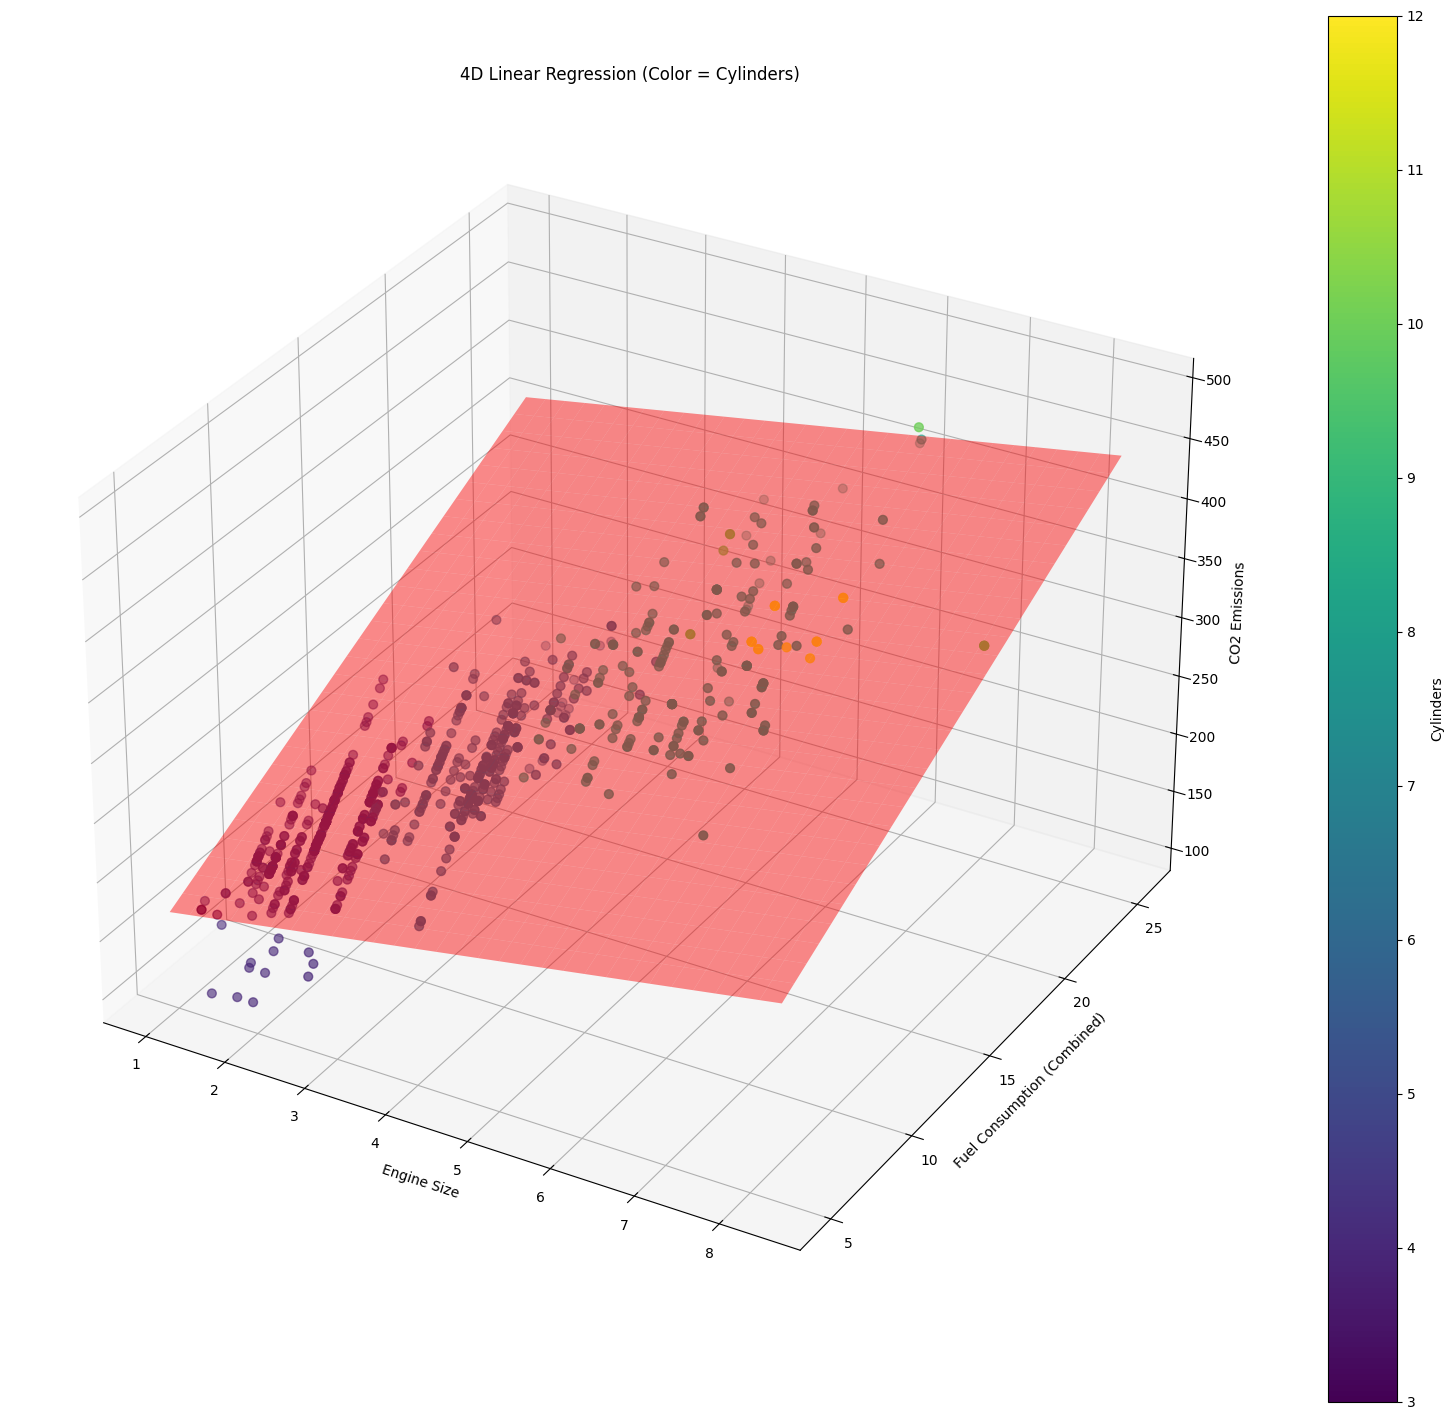

In [11]:
# Dataset columns
X1 = train["ENGINESIZE"]
X2 = train["FUELCONSUMPTION_COMB"]
X3 = train["CYLINDERS"]
Y  = train["CO2EMISSIONS"]

# Model coefficients
coef1 = regr.coef_[0][0]
coef2 = regr.coef_[0][2]
coef3 = regr.coef_[0][1]
inter = regr.intercept_[0]

# Create a grid for the regression surface
x1_range = np.linspace(X1.min(), X1.max(), 30)
x2_range = np.linspace(X2.min(), X2.max(), 30)
x1_grid, x2_grid = np.meshgrid(x1_range, x2_range)

# Use the mean value of CYLINDERS for the surface
x3_mean = X3.mean()

# Regression plane equation
y_pred_grid = inter + coef1*x1_grid + coef2*x2_grid + coef3*x3_mean

# Plot figure
fig = plt.figure(figsize=(20,18))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot (4D: color = CYLINDERS)
p = ax.scatter(X1, X2, Y, c=X3, cmap='viridis', s=40)
cbar = plt.colorbar(p)
cbar.set_label("Cylinders")

# Regression surface
ax.plot_surface(x1_grid, x2_grid, y_pred_grid, alpha=0.45, color='red')

# Axis labels
ax.set_xlabel("Engine Size")
ax.set_ylabel("Fuel Consumption (Combined)")
ax.set_zlabel("CO2 Emissions")

plt.title("4D Linear Regression (Color = Cylinders)")
plt.show()


<h1 id = "Evaluation">Evaluation</h1>

In [12]:
r2_score?

Signature:
r2_score(
    y_true,
    y_pred,
    *,
    sample_weight=None,
    multioutput='uniform_average',
    force_finite=True,
)
Docstring:
:math:`R^2` (coefficient of determination) regression score function.

Best possible score is 1.0 and it can be negative (because the
model can be arbitrarily worse). In the general case when the true y is
non-constant, a constant model that always predicts the average y
disregarding the input features would get a :math:`R^2` score of 0.0.

In the particular case when ``y_true`` is constant, the :math:`R^2` score
is not finite: it is either ``NaN`` (perfect predictions) or ``-Inf``
(imperfect predictions). To prevent such non-finite numbers to pollute
higher-level experiments such as a grid search cross-validation, by default
these cases are replaced with 1.0 (perfect predictions) or 0.0 (imperfect
predictions) respectively. You can set ``force_finite`` to ``False`` to
prevent this fix from happening.

Note: when the prediction residuals hav

In [13]:
test_x = np.asanyarray(test[["ENGINESIZE","CYLINDERS","FUELCONSUMPTION_COMB"]])
test_y = np.asanyarray(test[["CO2EMISSIONS"]])
test_y_ = regr.predict(test_x)
print("MAE : " , np.mean(np.absolute(test_y_ - test_y)))
print("MSE : " , np.mean(np.square(test_y_ - test_y)))
print("R2_score : ",r2_score(test_y,test_y_))

MAE :  15.285271420814192
MSE :  457.38903718877015
R2_score :  0.8776636749014726
